<a href="https://colab.research.google.com/github/T-Svitlichna/olist-analytics-DTAA-2026/blob/main/Python/notebook/coffee_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Прогнозування продажів кав'ярні (Forecast)

## Завдання з машинного навчання для початківців

У цьому проєкті ви навчите просту модель, яка **прогнозує майбутні продажі** на основі минулих даних. Ми використаємо `scikit-learn` — найпопулярнішу бібліотеку машинного навчання в Python.

**Не хвилюйтесь, якщо мало досвіду з Python** — більшість коду вже написана. Ваше завдання:
1. Запускати клітинки по черзі (Shift + Enter)
2. Заповнити кілька пропусків, позначених `# ⬅️ ВАШ КОД`
3. **Головне — інтерпретувати результати** (відповіді пишіть у клітинках з питаннями)

---

### Легенда
Ви — аналітик мережі кав'ярень **"CoffeeTime"**. У вас є дані про щомісячну виручку за 3 роки (2022–2024). Директор хоче знати: **скільки ми зароблятимемо в наступні місяці?** Побудуйте прогноз і поясніть його простими словами.

## Крок 1. Підключаємо бібліотеки

Спочатку завантажимо потрібні інструменти. Просто запустіть цю клітинку — тут нічого міняти не треба.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Бібліотеки підключено! ✅")

Бібліотеки підключено! ✅


## Крок 2. Завантажуємо дані

Прочитаємо файл `coffee_sales.csv` і подивимось на перші рядки.

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/T-Svitlichna/ShopSphere/refs/heads/main/Python/data/coffee_sales.csv")

# Подивимось на перші 5 рядків
df.head()

,month_number,year,month,month_name,revenue
0,1,2022,1,Січень,12499
1,2,2022,2,Лютий,11712
2,3,2022,3,Березень,14006
3,4,2022,4,Квітень,15618
4,5,2022,5,Травень,14688


**Що означають стовпці:**
- `month_number` — порядковий номер місяця (1, 2, 3 ... 36). Це наш **головний вхідний параметр** (X)
- `year`, `month`, `month_name` — рік, номер і назва місяця (для зручності)
- `revenue` — виручка за місяць у гривнях. Це те, що ми **прогнозуємо** (y)

In [5]:
# Скільки в нас даних?
print(f"Кількість місяців у даних: {len(df)}")
print(f"Перший місяць: {df['revenue'].iloc[0]} грн")
print(f"Останній місяць: {df['revenue'].iloc[-1]} грн")

Кількість місяців у даних: 36
Перший місяць: 12499 грн
Останній місяць: 30642 грн


## Крок 3. Дивимось на дані очима

Перш ніж щось прогнозувати, аналітик **завжди спочатку дивиться на графік**. Побудуємо графік виручки за всі 36 місяців.

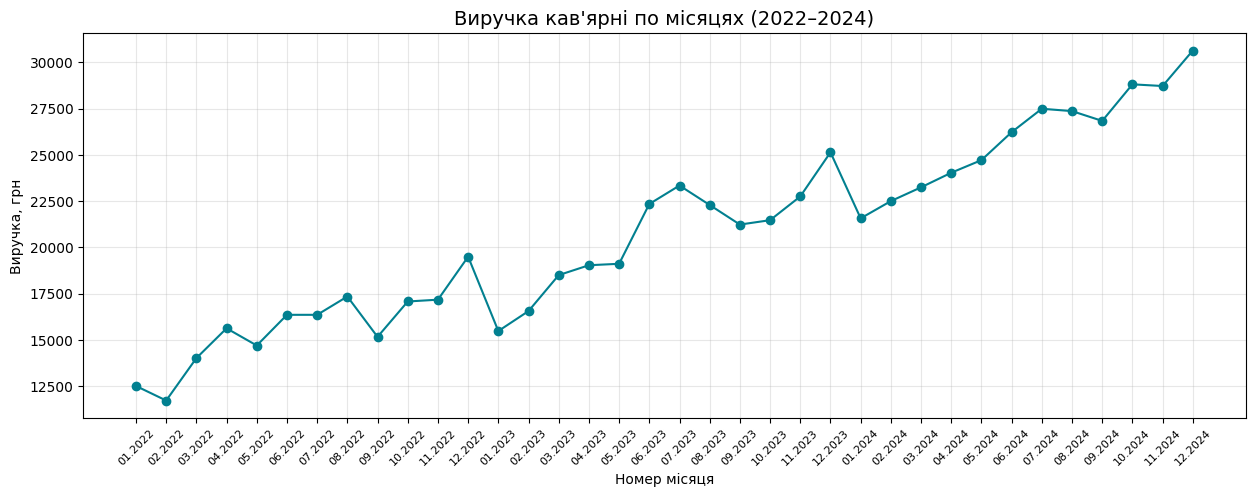

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090")
plt.title("Виручка кав'ярні по місяцях (2022–2024)", fontsize=14)
labels = df["month"].astype(str).str.zfill(2) + "." + df["year"].astype(str)
plt.xticks(df["month_number"], labels, rotation=45, fontsize=8)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 1 (інтерпретація)

Подивіться на графік уважно і дайте відповідь текстом:

1. Який **загальний напрямок** руху виручки? (зростає / падає / стоїть на місці)
2. Чи бачите ви якісь **регулярні коливання** (наприклад, сезонні піки влітку чи взимку)?
3. Як гадаєте, чи можна за таким графіком приблизно вгадати, що буде далі?

**Ваша відповідь:**

*(напишіть тут, двічі клікнувши на цю клітинку)*

1. Загальний рух виручки на графіку показує зростання в цілому. Кожен рік виручка збільшується в порівнянні в попереднім
2. Падіння спостерігається кожні 4 місяці в 01, 05, 09, майже завжди, окрім 2022 року. В цьому році зниження виручки було в лютому. В той же час пік зростання виручки можна побачити в грудні та в літні місяці 8 місяць 2022 року та 7 місяць 2023-2024 років. Також спостерігається зростання виручки весною переважно в 4 - му місяці.
3. За таким графіком, продовжуючи уявний тренд зростання можна передбачити, що виручка наступного року буде так само зростати з вище описаними коливаннями, за умови аналогічної можелі ведення бізнесу та умов ринку. Точніші цифри може дати побудована модель лінійної регресії.


## Крок 4. Готуємо дані для моделі

Модель навчається на парах «вхід → вихід». У нас:
- **Вхід (X)** — номер місяця (`month_number`)
- **Вихід (y)** — виручка (`revenue`)

Модель шукатиме залежність: «як виручка залежить від номера місяця».

In [13]:
# X — вхідні дані (features). Подвійні дужки [[ ]] потрібні, щоб отримати таблицю, а не список
X = df[["month_number"]]

# y — те, що прогнозуємо (target)
y = df["revenue"]

print("X (перші 3):")
print(X.head(3))
print("\ny (перші 3):")
print(y.head(3))

X (перші 3):
   month_number
0             1
1             2
2             3

y (перші 3):
0    12499
1    11712
2    14006
Name: revenue, dtype: int64


## Крок 5. Навчаємо модель

Тепер найголовніше — навчання. Ми використаємо **лінійну регресію** — найпростішу модель, яка проводить пряму лінію крізь наші точки.

Модель за нас знайде два числа:
- **нахил (slope)** — на скільки гривень зростає виручка щомісяця
- **перетин (intercept)** — з якого рівня все починалось

Заповніть один пропуск нижче: викличте `.fit(X, y)`, щоб навчити модель.

In [14]:
# Створюємо модель
model = LinearRegression()

# Навчаємо модель на наших даних
model.fit(X, y)


print("Модель навчено! ✅")
print(f"Нахил (slope): {model.coef_[0]:.0f} грн на місяць")
print(f"Перетин (intercept): {model.intercept_:.0f} грн")

Модель навчено! ✅
Нахил (slope): 459 грн на місяць
Перетин (intercept): 12247 грн


### ❓ Питання 2 (інтерпретація)

Модель порахувала **нахил (slope)**. Це найважливіше число прогнозу.

1. Чому дорівнює нахил? Що він означає **простими словами** для директора кав'ярні?
   (Підказка: «Щомісяця виручка в середньому зростає на ___ грн»)
2. Перетин (intercept) — це теоретична виручка в «місяць 0». Чи має він реальний бізнес-сенс тут?

**Ваша відповідь:**
1. Значення Нахил (slope): 459 грн на місяць означає, що виручка щомісяця зрстає в середньому на 459грн. щомісяця, враховуючи всі коливання.
2. Значення Перетин (intercept): 12247 грн позакує початкову виручку, стартову точку нашого дослідження в січні 2022 року. Це має сенс  як стартове значення виручки для нашого прогнозу.
...


## Крок 6. Перевіряємо, як модель описує минуле

Спочатку подивимось, наскільки добре пряма лінія моделі лягає на реальні дані. Побудуємо графік: реальні точки + лінія прогнозу.

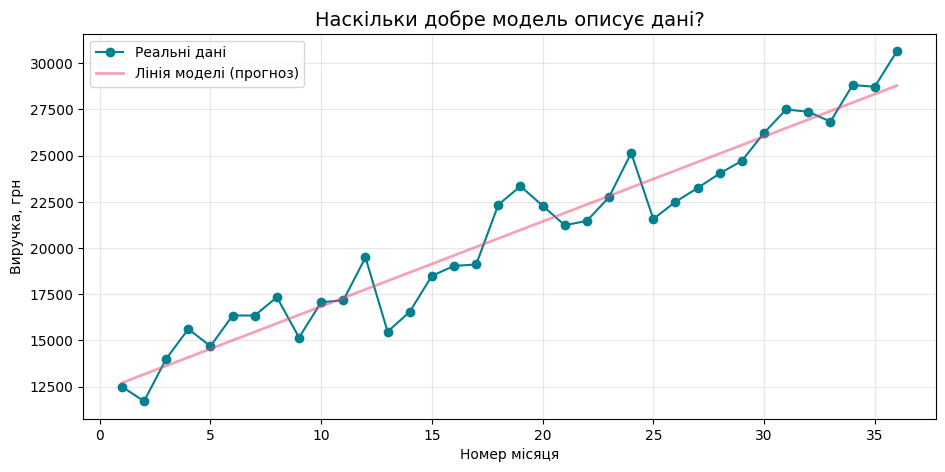

In [26]:
# Прогноз моделі для всіх наявних місяців
df["predicted"] = model.predict(X)

plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Реальні дані")
plt.plot(df["month_number"], df["predicted"], color="#EF476F", linewidth=2, label="Лінія моделі (прогноз)", alpha  = 0.5)
plt.title("Наскільки добре модель описує дані?", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 3 (інтерпретація)

1. Наскільки добре червона лінія «ловить» загальний тренд синіх точок?
2. Точки не лежать ідеально на лінії — вони то вище, то нижче. **Чому**, на вашу думку? (згадайте про сезонність)
3. Чи вважаєте ви, що проста пряма лінія — це достатньо добре для директора, чи потрібна складніша модель?

**Ваша відповідь:**
1. Лінія моделі добре показує напрямок зростання виручки, відображення цілком зрозуміле та відображає реальний тренд наших данний, вона враховує також зміну величини виручки як в сторону зростання так і в сторону спадання.
2. Точки ревеню розтащовані по обидві сторони лінії нашої моделі показують як сезонні коливанні, описані вище, так і поодинокі підвищення та зниження виручки. Це абсолютно нормально для показників виручки відносно часу і життєвому циклі бізнесу.
3. В даному випадку проста пряма лінія є найнагляднішою та простою  для розуміння тенденції зростання виручки в майбутньому. Якщо для бізнесу буде критично розуміти не тілки загальне зростання при стабільних умовах, а й прогнозні значення коливань, тут допоможе модель  Модель з сезонністю (Holt-Winters),  яка створить прогноз з врахуванням істторичних коливань.
...


## Крок 7. 🔮 Прогноз на майбутнє

А тепер — головне, заради чого все робилось. Спрогнозуємо виручку на **наступні 6 місяців** (місяці 37–42, тобто перша половина 2025 року).

Заповніть пропуск: створіть список майбутніх номерів місяців від 37 до 42.

In [22]:
# Майбутні місяці: 37, 38, 39, 40, 41, 42
future_months = pd.DataFrame({"month_number": [37, 38, 39, 40, 41, 42]})   # ⬅️ ВАШ КОД

# Прогнозуємо виручку для них
future_predictions = model.predict(future_months)

# Показуємо результат
for m, pred in zip(future_months["month_number"], future_predictions):
    print(f"Місяць {m}: прогноз ≈ {pred:.0f} грн")

Місяць 37: прогноз ≈ 29242 грн
Місяць 38: прогноз ≈ 29701 грн
Місяць 39: прогноз ≈ 30161 грн
Місяць 40: прогноз ≈ 30620 грн
Місяць 41: прогноз ≈ 31079 грн
Місяць 42: прогноз ≈ 31539 грн


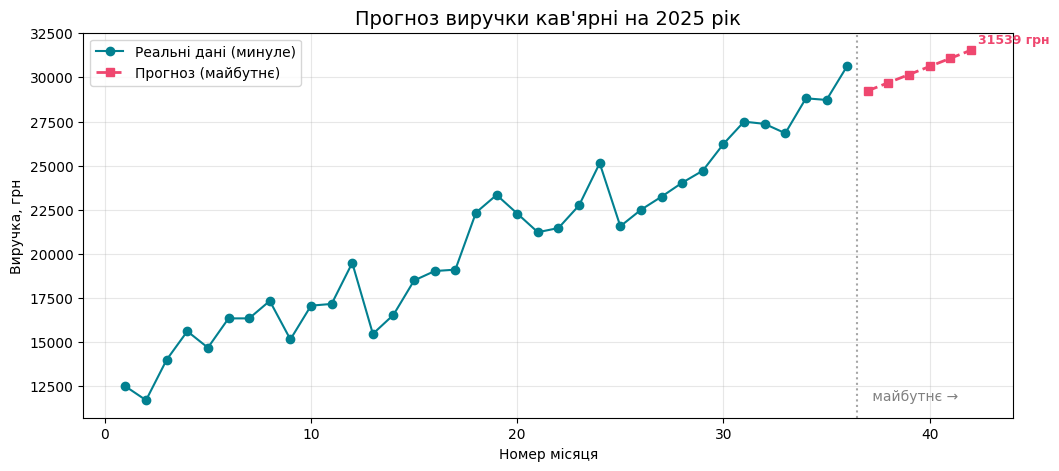

In [29]:
# Побудуємо фінальний графік: минуле + прогноз
plt.figure(figsize=(12, 5))

# Реальні дані
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Реальні дані (минуле)")
# Підпис тільки для місяця 42
pred_42 = future_predictions[future_months["month_number"] == 42][0]
plt.annotate(f"{pred_42:.0f} грн",
            xy=(42, pred_42),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            color="#EF476F",
            fontweight="bold")
# Прогноз на майбутнє
plt.plot(future_months["month_number"], future_predictions,
         marker="s", color="#EF476F", linewidth=2, linestyle="--", label="Прогноз (майбутнє)")

plt.axvline(x=36.5, color="gray", linestyle=":", alpha=0.7)
plt.text(37, df["revenue"].min(), " майбутнє →", color="gray")
plt.title("Прогноз виручки кав'ярні на 2025 рік", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

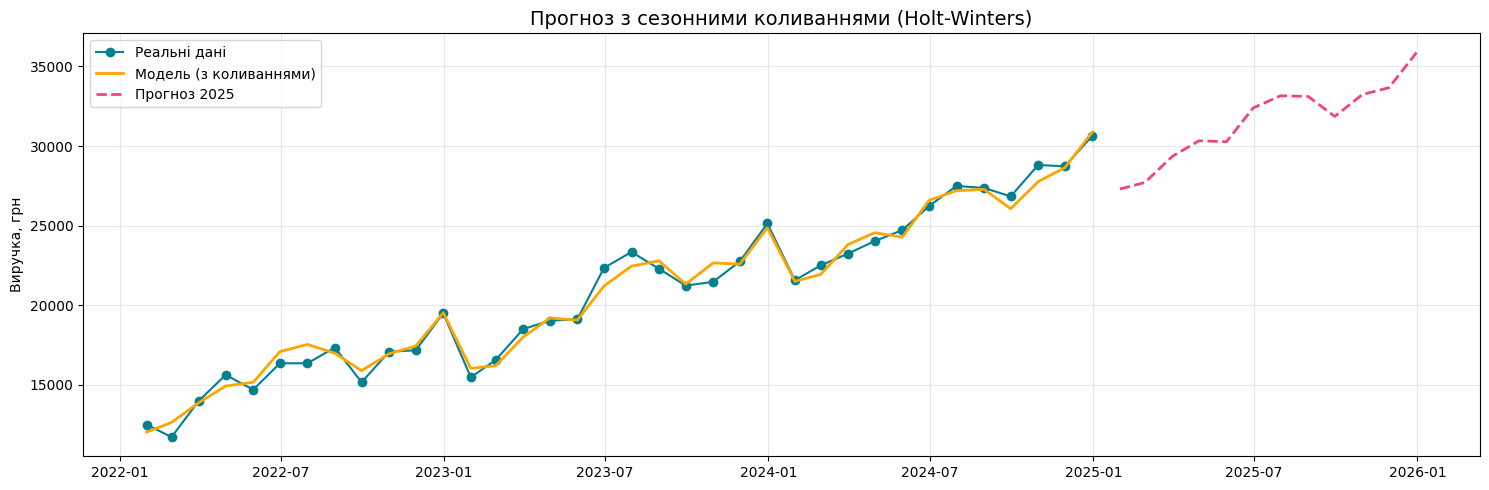

In [ ]:
# @title
# Модель з сезонним коливаннями
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Створюємо часовий ряд
ts = pd.Series(df["revenue"].values,
               index=pd.date_range(start="2022-01", periods=len(df), freq="ME"))

# Модель з сезонністю (Holt-Winters)
model_hw = ExponentialSmoothing(ts,
                                trend="add",
                                seasonal="add",
                                seasonal_periods=12)
fit_hw = model_hw.fit()

# Прогноз на 12 місяців вперед
forecast = fit_hw.forecast(12)

# Графік
plt.figure(figsize=(15, 5))
plt.plot(ts.index, ts, marker="o", color="#028090", label="Реальні дані")
plt.plot(ts.index, fit_hw.fittedvalues, color="orange", linewidth=2, label="Модель (з коливаннями)")
plt.plot(forecast.index, forecast, color="#EF476F", linewidth=2, linestyle="--", label="Прогноз 2025")
plt.title("Прогноз з сезонними коливаннями (Holt-Winters)", fontsize=14)
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Цей прогноз більш точніший, тому що враховує сезонність. Але навіть такий прогноз може бути хибном, якщо в майбутньому б бізнесі відбуватимуться непердбачені зміни, викликані зовнішніми чи внутрішніми факторами.

### ❓ Питання 4 (інтерпретація — найважливіше!)

1. Яку виручку модель прогнозує на **місяць 42** (червень 2025)?
2. Директор питає: «**Чи можна повністю довіряти цьому прогнозу?**» Що ви відповісте? Назвіть хоча б **дві причини**, чому реальність може відрізнятись від прогнозу.
3. Наша модель малює **пряму лінію** — вона припускає, що зростання триватиме вічно тим самим темпом. У яких ситуаціях це припущення може бути **небезпечним** для бізнесу?

**Ваша відповідь:**

1. на 42 місяць модель прогнозує іиручку у розмірі 31539 грн
2. Директор може довіряти показникам зростання виручки в цій можелі, тільки як орієнтовним, за умови що фактори, які впливають на його виручку залишаться незмінними, або матимуть незначні коливання. Якщо ж відбуватимуться системні  проблеми, які приведуть до зменшення виручки в наслідок внутрішніх факторів(проблеми з персоналом, перебої з постачанням, проблеми з якістю та ін) або зовнішніх факторів(появлення конкурентів, системне відставання від нових тенденцій в цьому бізнесі, економічні кризи та  інші форс-мажорні обставини), тоді необхідно буде будувати можель виходячи з нових обставин.
3. Наразі це ідеальна модель, яка не враховує нових чинників, які можуть чинити вплив на бізнес в майбутньому. Як позитивних так і негативних. Також не відображає значення сезонних та іншмх коливань виручки, притаманні цьому бізнесу. Зважаючи на це, прогнозний показник може не співпадати з реальним суттєво.


## Крок 8. ⭐ Бонусне завдання (необов'язкове)

Спробуйте спрогнозувати виручку на **один конкретний місяць** — наприклад, місяць 50 (лютий 2026).

Підказка: скопіюйте логіку з Кроку 7, але передайте лише одне число.

In [31]:
# Ваш експеримент тут:
one_month = pd.DataFrame({"month_number": [50]})
prediction = model.predict(one_month)
print(f"Прогноз на місяць 50: {prediction[0]:.0f} грн")

# ❓ Питання-бонус: чим ДАЛІ в майбутнє ми прогнозуємо, тим прогноз...
#    (надійніший чи менш надійний?) Чому? Напишіть відповідь коментарем нижче:
# Відповідь: Чим далі ми прогнозуємо, тим більше може наш прогноз відрізнятися від реальності, адже наш прогноз не може передбачити всіх зовнішніх та внутрішніх факторів, які впливатимуть на тенденції розвитку нашого кафе.

Прогноз на місяць 50: 35213 грн


## 🎓 Підсумок

Вітаємо! Ви щойно:
- ✅ Завантажили й дослідили реальні дані
- ✅ Навчили модель машинного навчання (лінійну регресію)
- ✅ Зробили прогноз на майбутнє
- ✅ **Найголовніше — навчились інтерпретувати результати й розуміти обмеження моделі**

### Що здати
Збережіть цей ноутбук з **усіма відповідями** на питання 1–4 (і бонус) та надішліть викладачу.

### Головний урок
Модель — це лише інструмент. Її прогноз рівно настільки хороший, наскільки хороші дані й наскільки розумно ви інтерпретуєте результат. **Аналітик, який розуміє обмеження моделі, цінніший за того, хто просто вміє натиснути `.fit()`.**